# Pacotes e dados experimentais

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from random import randint
from scipy.interpolate import interp1d
from scipy.constants import k as k_B

# PS: Pro programa funcionar a temperatura e deltaS_exp tem que ta exatamente no formato T_exp  = data["T(K)"].values e DS_exp = data["DS(J/kgK)"].values

# Conjunto de dados da variação entropia reversível
#data = pd.read_csv("delta_S_p2_rev_comp.csv", header=None).rename(columns={0:"T(K)",2:"DS(J/kgK)"})
#T_exp  = data["T(K)"].values
#DS_exp = data["DS(J/kgK)"].values

# Conjunto de dados da variação de entropia 
data = pd.read_csv("exp_data/delta_S_p2_comp.csv",header=None)
data.columns = ["T(K)", "DS(J/kgK)"]
T_exp = data["T(K)"].values
DS_exp = data["DS(J/kgK)"].values

# Conjunto de dados da entropia
data_3_p0 = pd.read_csv("exp_data/S_p0.csv",header=None) 
T_exp_3_p0 = data_3_p0[0]
S_exp_p0 = data_3_p0[1]

data_3_p2 = pd.read_csv("exp_data/S_p2.csv",header=None)
T_exp_3_p2 = data_3_p2[0]
S_exp_p2 = data_3_p2[1]

T_min = max(T_exp_3_p0.min(), T_exp_3_p2.min())
T_max = min(T_exp_3_p0.max(), T_exp_3_p2.max())

T_common = np.linspace(T_min, T_max, 500)

f0 = interp1d(T_exp_3_p0, S_exp_p0, kind='linear', fill_value="extrapolate")
f2 = interp1d(T_exp_3_p2, S_exp_p2, kind='linear', fill_value="extrapolate")

S0_interp = f0(T_common)
S2_interp = f2(T_common)

# Frequencias
data_freq = pd.read_csv("normal_modes_calc_orca/modos_normais_oct.csv",decimal=",")
frequencias_HS = data_freq["HighSpin"]
frequencias_LS = data_freq["LowSpin"]

# Frequencias foram utilizadas para o fit.
data_freq = pd.read_csv("normal_modes_calc_orca/modos_normais_oct.csv",decimal=",")
#frequencias_HS = data_freq["HighSpin"] # < 2000
#frequencias_LS = data_freq["LowSpin"]  # < 2000

frequencias_HS = pd.read_csv("normal_modes_calc_orca/HS_modes_freq.txt",sep=",")["Frequencia (cm-1)"] # All
frequencias_LS = pd.read_csv("normal_modes_calc_orca/LS_modes_freq.txt",sep=",")["Frequencia (cm-1)"] # All

# Funções e Constantes

In [72]:
##########################################################
# Constantes
##########################################################
R = 8.314 # J/molK
k_B = 1.380649e-23
mu_B = 9.2740100783e-24
M = 0.540273 # kg/mol

P_init = 101325 # pressão inicial em bar
P_fin = 200e6 # pressão final em bar
##########################################################
# Funções auxiliares
##########################################################
def T_model(m, delta_0, delta_V, P, g, T0):
    P_linha = (((delta_V) * P)) / 4
    gamma = (delta_0 + P_linha/k_B) / (T0)
    numerator = 2 * (m - gamma)
    denominator = np.log((m + 1) / (g**2 * (1 - m)))
    return T0 * (numerator / denominator)

def S_C(n_hs):
    return -R/M*(n_hs*np.log(n_hs) + (1-n_hs)*np.log(1-n_hs))

def S_S(T, g_J, J, B):
    x = (g_J * mu_B * J * B) / (k_B * T)
    num = np.sinh((2 * J + 1) * x / (2 * J))
    den = np.sinh(x / (2 * J))
    Z = num / den
    coeff = (2 * J + 1) / (2 * J)
    B_J = (coeff / np.tanh(coeff * x)) - (1 / (2 * J * np.tanh(x / (2 * J))))
    return R/M * (np.log(Z) + x * B_J)

def S_O(limite_soma, T, frequencias_cm):
    hbar = 1.054571817e-34
    c = 1
    beta = 1/(k_B*T)
    soma = 0.0
    for omega_cm in frequencias_cm:
        omega = 2*np.pi*c*omega_cm
        x = beta*hbar*omega
        if x == 0: 
            continue
        termo_log = -np.log(1 - np.exp(-x))
        termo_fracao = x/(np.exp(x) - 1)
        soma += termo_log + termo_fracao
    return R/M * soma
##########################################################
# Cálculo de ΔS e componentes no grid pedido (T_common)
##########################################################
def calc_deltaS_components(params, fixed, T_common, P_amb=P_init, P_high=P_fin,
                           freq_HS=frequencias_HS, freq_LS=frequencias_LS):
    # Usa valores fixos + ajustáveis
    T0      = params.get("T0",     fixed["T0"])
    g       = params.get("g",      fixed["g"])
    Delta0  = params.get("Delta0", fixed["Delta0"])
    delta_V = params.get("deltaV", fixed["deltaV"])

    # Varredura em m -> gera T(m) para P_init e P_fin
    m_vals = np.linspace(-0.999, 0.999, 10000)
    Temp_amb  = T_model(m_vals, Delta0, delta_V, P_amb,  g, T0)
    Temp_high = T_model(m_vals, Delta0, delta_V, P_high, g, T0)
    n_hs_vals = (m_vals+1)/2

    # Interpolar fração HS para T_common
    n_hs_amb  = np.interp(T_common, Temp_amb,  n_hs_vals)
    n_hs_high = np.interp(T_common, Temp_high, n_hs_vals)

    # (1) Configuracional
    delta_S_Config = -(S_C(n_hs_high) - S_C(n_hs_amb))

    # (2) Spin
    S_S_amb  = n_hs_amb  * S_S(T_common, 2, 2, 0.01)
    S_S_high = n_hs_high * S_S(T_common, 2, 2, 0.01)
    delta_S_Spin = -(S_S_high - S_S_amb)

    # (3) Óptica
    freq_HS=list(frequencias_HS)
    freq_LS=list(frequencias_LS)
    S_O_HS = np.array([S_O(len(freq_HS), T, freq_HS) for T in T_common])
    S_O_LS = np.array([S_O(len(freq_LS), T, freq_LS) for T in T_common])
    S_O_high = n_hs_high*S_O_HS + (1-n_hs_high)*S_O_LS
    S_O_amb  = n_hs_amb *S_O_HS + (1-n_hs_amb )*S_O_LS
    delta_S_O = -(S_O_high - S_O_amb)

    delta_S_total = delta_S_Config + delta_S_Spin + delta_S_O
    return delta_S_total, delta_S_Config, delta_S_Spin, delta_S_O

##########################################################
# Alinhar dados ao grid comum e limitar intervalo de fit
##########################################################
def align_to_common_grid(T_exp, DS_exp, T_range=None, n_points=None):
    """Cria T_common igualmente espaçado dentro de T_range
       e interpola DS_exp para T_common.
    """
    # Limpeza, ordenação e máscara de intervalo
    T_exp = np.asarray(T_exp)
    DS_exp = np.asarray(DS_exp)
    # ordenar
    order = np.argsort(T_exp)
    T_exp = T_exp[order]
    DS_exp = DS_exp[order]
    # remover temperaturas duplicadas (mantém a média do DS nelas)
    T_unique, idxs = np.unique(T_exp, return_index=True)
    if len(T_unique) != len(T_exp):
        # média por temperatura
        df_tmp = pd.DataFrame({"T":T_exp, "DS":DS_exp}).groupby("T", as_index=False).mean()
        T_exp = df_tmp["T"].values
        DS_exp = df_tmp["DS"].values

    # intervalo
    if T_range is not None:
        tmin, tmax = T_range
        mask = (T_exp >= tmin) & (T_exp <= tmax)
        T_exp = T_exp[mask]
        DS_exp = DS_exp[mask]

    if n_points is None:
        n_points = len(T_exp)  # por padrão: mesmo nº de pontos do experimento no intervalo

    # criar grid comum e interpolar DS experimental nele
    T_common = np.linspace(T_exp.min(), T_exp.max(), 500)
    DS_exp_common = np.interp(T_common, T_exp, DS_exp)

    return T_common, DS_exp_common

##########################################################
# Rotina de ajuste (com intervalo e alinhamento)
##########################################################
def fit_params(T_exp, DS_exp, to_fit=("g","Delta0"),
               init_guess={"T0":310,"g":4000,"Delta0":2500,"deltaV":43e-30},
               bounds={"T0":(200,400),"g":(1000,10000),"Delta0":(1000,5000),"deltaV":(1e-31,1e-28)},
               T_range=(290,350), n_points=None,
               freq_HS=frequencias_HS, freq_LS=frequencias_LS,
               P_amb=101325, P_high=200e6):

    # Alinhar e interpolar experimental → T_common no intervalo escolhido
    T_common, DS_exp_common = align_to_common_grid(T_exp, DS_exp, T_range=T_range, n_points=n_points)

    fixed = init_guess.copy()
    var_names = list(to_fit)
    x0   = [init_guess[p] for p in var_names]
    bnds = np.array([bounds[p] for p in var_names]).T  # shape (2, n)

    def residuals(x):
        params = {p:val for p,val in zip(var_names, x)}
        DS_model,_,_,_ = calc_deltaS_components(params, fixed, T_common,
                                                P_amb=P_amb, P_high=P_high,
                                                freq_HS=frequencias_HS, freq_LS=frequencias_LS)
        return DS_model - DS_exp_common

    res = least_squares(residuals, x0, bounds=bnds)
    fitted = {p:val for p,val in zip(var_names, res.x)}

    # Curvas finais (total e componentes) já no T_common
    DS_fit, DS_conf, DS_spin, DS_opt = calc_deltaS_components(fitted, fixed, T_common,
                                                              P_amb=P_amb, P_high=P_high,
                                                              freq_HS=frequencias_HS, freq_LS=frequencias_LS)
    out = {
        "fitted_params": fitted,
        "result": res,
        "T_common": T_common,
        "DS_exp_common": DS_exp_common,
        "DS_fit": DS_fit,
        "DS_conf": DS_conf,
        "DS_spin": DS_spin,
        "DS_opt": DS_opt
    }
    return out

# Plot Fit

In [52]:
# =========================
# Parameters
# =========================
g = 1583.9068323925048
Delta0 = 2312.6566579556024
T0 = 158.51641568665738

# Pressures (Pa)
P_init = 101325        # ~1 atm
#P_init = 0
P_fin  = 200e6         # 200 MPa

# You did not specify delta_V.
# Example value (adjust to your system)
delta_V = 75e-30  # m^3

# =========================
# Model
# =========================
def T_model(m, delta_0, delta_V, P, g, T0):
    P_linha = (delta_V * P) / 4
    gamma = (delta_0 + P_linha / k_B) / T0

    numerator = 2 * (m - gamma)
    denominator = np.log((m + 1) / (g**2 * (1 - m)))

    return T0 * (numerator / denominator)

# =========================
# m range
# =========================
m = np.linspace(-0.9999, 0.9999, 5000)

# Temperatures
T_init = T_model(m, Delta0, delta_V, P_init, g, T0)
T_fin  = T_model(m, Delta0, delta_V, P_fin,  g, T0)

In [73]:
# Rodar ajuste no intervalo 290–350 K, usando mesmo nº de pontos do experimento nesse intervalo
T_min = 280
T_max = 380
out = fit_params(T_exp,DS_exp,
                 to_fit=("g","Delta0","T0"),  # parametros a serem fitados
                 init_guess={"T0":250,"g":1000,"Delta0":2000,"deltaV":75e-30}, # chute inicial dos parametros
                 bounds={"T0":(100,650),"g":(800,20000),"Delta0":(1000,5000),"deltaV":(30e-30,50e-30)}, # limites em que os parametros vão variar
                 T_range=(T_min,T_max), n_points=None) # range da temperatura que sera feito o fit

print("Parâmetros ajustados:", out["fitted_params"])

Parâmetros ajustados: {'g': np.float64(1457.8585779072027), 'Delta0': np.float64(2285.193905897288), 'T0': np.float64(162.190315452524)}


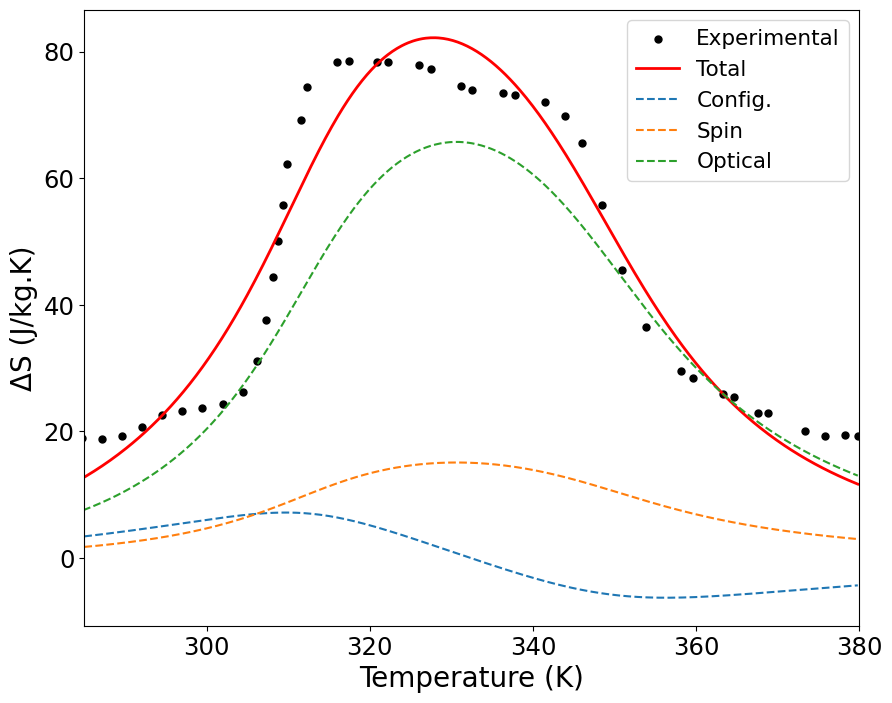

In [74]:
fig, ax = plt.subplots(figsize=(10,8))

ax.scatter(
    data["T(K)"].values,
    data["DS(J/kgK)"].values,
    label="Experimental",
    s=25,
    color='black'
)

ax.plot(
    out["T_common"],
    out["DS_fit"],
    label="Total",
    linewidth=2,
    color='red'
)

ax.plot(
    out["T_common"],
    out["DS_conf"],
    label="Config.",
    ls="--"
)

ax.plot(
    out["T_common"],
    out["DS_spin"],
    label="Spin",
    ls="--"
)

ax.plot(
    out["T_common"],
    out["DS_opt"],
    label="Optical",
    ls="--"
)

ax.set_xlabel("Temperature (K)", fontsize=20)
ax.set_ylabel("ΔS (J/kg.K)", fontsize=20)

ax.tick_params(axis="both", labelsize=17.5)
ax.legend(fontsize=15.5)
ax.set_xlim(285, 380)

fig.savefig(
    "fig_ds_fit.pdf",
    bbox_inches='tight'
)

In [79]:
 max(out["DS_opt"])/max(data["DS(J/kgK)"].values)

np.float64(0.8365626256804766)

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

k_B = 1.380649e-23

g = 1457.8585779072027
Delta0 = 2285.193905897288
T0 = 162.190315452524
deltaV = 75e-30

# Temperaturas desejadas
T_grid = np.linspace(280, 350, 500)

m_values = []

for T_target in T_grid:

    def f(m):
        return T_model(m, Delta0, deltaV, 0, g, T0) - T_target

    try:
        m_sol = brentq(f, -0.999999, 0.999999)
        m_values.append(m_sol)
    except:
        m_values.append(np.nan)

print("A temperatura de transição é:",T_model(0, Delta0, 48e-30, 0, g, T0))

A temperatura de transição é: 313.69670751553156


# Overlap Normal Modes

In [27]:
%matplotlib qt
import pandas as pd
import re
import numpy as np
from io import StringIO   # <-- use isto
import matplotlib.pyplot as plt
import mplcursors
#%matplotlib widget # Isso anula usar o matplotlib qt
#%matplotlib notebook

In [28]:
hs = pd.read_csv("normal_modes_calc_orca/Oct_Contri_hs.csv")
ls = pd.read_csv("normal_modes_calc_orca/Oct_Contri_ls.csv")

In [29]:
def renomear_index_por_atom(df, lista_atomica):
    """
    df: DataFrame final já criado (159 linhas)
    lista_atomica: lista de strings com linhas contendo símbolo, massa e coordenadas
    """
    # Extrair apenas o símbolo atômico de cada linha
    simbolos = [linha.split()[0] for linha in lista_atomica]

    novo_index = []
    contadores = {}  # exemplo: {"C":1, "H":1, "O":1}

    for simbolo in simbolos:
        if simbolo not in contadores:
            contadores[simbolo] = 1

        nome = f"{simbolo}{contadores[simbolo]}"

        # Cada átomo corresponde a 3 linhas do DataFrame
        novo_index.extend([nome, nome, nome])

        contadores[simbolo] += 1

    # Aplicar ao DataFrame
    df.index = novo_index
    return df

In [30]:
lista_atomica = [
    "C     12.01100     -5.520264845720    -1.115707479413     0.897605357711",
    "C     12.01100      5.520452518574    -1.115723577676    -0.897303843581",
    "C     12.01100     -4.717428065189    -2.832744402920    -1.052293345657",
    "C     12.01100      4.717889260456    -2.832871384362     1.052539744557",
    "C     12.01100     -6.606891583710    -4.394353536396    -2.145371212533",
    "C     12.01100      6.607390344081    -4.394770037602     2.145057663476",
    "H      1.00800     -6.034676638152    -5.702671048362    -3.610513207819",
    "H      1.00800      6.035355292474    -5.703243699406     3.610128208214",
    "C     12.01100     -9.066360064720    -4.254075940367    -1.367474199670",
    "C     12.01100      9.066728222324    -4.254628795559     1.366661179528",
    "H      1.00800    -10.511265866955    -5.441454535473    -2.193507432040",
    "H      1.00800     10.511683451023    -5.442288278089     2.192214608511",
    "C     12.01100     -9.770578178244    -2.550150813499     0.537008619724",
    "C     12.01100      9.770715542304    -2.550563288206    -0.537744580628",
    "C     12.01100     -8.020310169408    -0.994075397066     1.671451991949",
    "C     12.01100      8.020340638195    -0.994159763824    -1.671623622263",
    "N     14.00700    -12.378556223629    -2.409089787803     1.327755332438",
    "N     14.00700     12.378519201596    -2.409668247301    -1.329083667815",
    "O     15.99900     -2.416219571234    -2.903288706253    -1.747879105684",
    "O     15.99900      2.416744722791    -2.903297471670     1.748496268000",
    "O     15.99900    -13.888079551984    -3.808782207744     0.304531482779",
    "O     15.99900     13.888086558489    -3.809858819272    -0.306655649681",
    "O     15.99900    -12.928247729108    -0.893379703175     2.972383430461",
    "O     15.99900     12.927953998234    -0.893763939771    -2.973651371779",
    "N     14.00700     -3.564693824940     0.330596326795     1.821477061978",
    "N     14.00700      3.564735878326     0.330650146953    -1.820781402117",
    "H      1.00800     -8.649557134583     0.282766099379     3.140249066382",
    "H      1.00800      8.649412269810     0.282821974285    -3.140385031032",
    "C     12.01100     -3.655291153411     2.031063880783     3.536851991090",
    "C     12.01100      3.655056986834     2.030838091497    -3.536441828175",
    "H      1.00800     -5.377071945919     2.549964151628     4.541848489297",
    "C     12.01100     -1.310384408628     3.291486455883     4.191970491532",
    "C     12.01100      1.310046939264     3.291108840358    -4.191443794614",
    "H      1.00800      5.376641385352     2.549464552762    -4.541919460723",
    "N     14.00700      0.741387328905     2.577206192449     2.876254138590",
    "C     12.01100     -1.181804924987     5.094014086095     6.099820375343",
    "C     12.01100      1.181227147302     5.093277810341    -6.099625154786",
    "N     14.00700     -0.741599888669     2.576856952799    -2.875508194828",
    "C     12.01100      2.955085757498     3.593295877611     3.458276208785",
    "H      1.00800     -2.881312278661     5.626521498741     7.109401298976",
    "C     12.01100      1.133402062841     6.155165171408     6.683444521954",
    "H      1.00800      2.880649251831     5.625718623776    -7.109394845466",
    "C     12.01100     -1.134093225637     6.154099585433    -6.683384268274",
    "C     12.01100     -2.955402360777     3.592657946625    -3.457669967266",
    "H      1.00800      4.565823766006     2.942241245285     2.371070162337",
    "C     12.01100      3.249950073085     5.383762691732     5.348576630598",
    "H      1.00800      1.287843102082     7.556621529536     8.167726618197",
    "C     12.01100     -3.250503942796     5.382767012137    -5.348272220948",
    "H      1.00800     -1.288716667155     7.555250245205    -8.167932773460",
    "H      1.00800     -4.566072050899     2.941572288416    -2.370400223201",
    "H      1.00800      5.104212185344     6.145690387923     5.751937690401",
    "H      1.00800     -5.104864181243     6.144415297879    -5.751727712650",
    "Fe    55.85000      0.000239285754    -0.441112578978     0.000655619575"
]

In [31]:
arquivo = "normal_modes_calc_orca/ls/v2/vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
     sep='\s+',
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
         sep='\s+',
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

In [32]:
df = renomear_index_por_atom(df, lista_atomica)
normal_modes_ls = df

In [33]:
arquivo = "normal_modes_calc_orca/hs/vib_mode.txt"

with open(arquivo, "r") as f:
    linhas = f.readlines()

# --------------------
# 1) Parte inicial (159 linhas)
# --------------------

linhas_159 = linhas[:159]

header = re.split(r"\s+", linhas[0].strip())
header = [h for h in header if h != ""]

df = pd.read_csv(
    StringIO("".join(linhas_159)),
    sep='\s+',
    names=header,
    skiprows=1
)

# --------------------
# 2) Blocos seguintes
# --------------------

blocos = []
i = 159

num_regex = r"^\s*\d+(\s+\d+)*\s*$"

while i < len(linhas):

    # Linha com números das colunas
    col_header_line = linhas[i].strip()
    novas_cols = re.split(r"\s+", col_header_line)
    novas_cols = [c for c in novas_cols if c != ""]
    i += 1

    bloco_linhas = []

    # Acumular linhas do bloco
    while i < len(linhas) and not re.match(num_regex, linhas[i]):
        bloco_linhas.append(linhas[i])
        i += 1

    # Se não houver linhas, pula
    if len(bloco_linhas) == 0:
        continue

    # ----------------------------
    # Detectar número real de colunas no bloco
    # ----------------------------
    primeira_linha = bloco_linhas[0].strip()
    ncols = len(re.split(r"\s+", primeira_linha))

    # criar nomes para todas as colunas
    # primeira é índice, outras são novas_cols (até onde existirem)
    nomes = ["idx"] + novas_cols + [f"extra_{k}" for k in range(len(novas_cols)+1, ncols)]

    df_bloco = pd.read_csv(
        StringIO("".join(bloco_linhas)),
        sep='\s+',
        names=nomes
    )

    df_bloco = df_bloco.drop(columns=["idx"])
    blocos.append(df_bloco)

# --------------------
# 3) Concatenar
# --------------------

for b in blocos:
    df = pd.concat([df, b], axis=1)

In [34]:
df = renomear_index_por_atom(df, lista_atomica)
normal_modes_hs = df

In [35]:
valores_modos_hs = pd.read_csv('normal_modes_calc_orca/ls/v2/freq_modos.txt',header=None,sep='\s+')[1]
valores_modos_ls = pd.read_csv('normal_modes_calc_orca/hs/freq_modos.txt',header=None,sep='\s+')[1]

In [36]:
# -------------------------
# 1) Monta a matriz (linhas = HS i, colunas = LS j)
# -------------------------
ini = 0
#ini = 6
lista_array_fin = []
for i in range(ini,159):
    iesimo_hs_nm = normal_modes_hs[str(i)]   # HS
    row = []
    for j in range(ini,159):
        jesimo_ls_nm = normal_modes_ls[str(j)]  # LS
        prod_intern_all = (iesimo_hs_nm * jesimo_ls_nm).sum()
        #row.append(abs(prod_intern_all))
        row.append((prod_intern_all))
    lista_array_fin.append(row)

prod_intern_all = pd.DataFrame(lista_array_fin)   # shape (HS, LS)
mat_all = prod_intern_all.to_numpy()
nrows_all, ncols_all = mat_all.shape

In [37]:
# -------------------------
# 2) Lê frequências corretamente (LS e HS)
#    (garante acesso posicional e tamanho compatível)
# -------------------------
valores_modos_ls = pd.read_csv(
    "normal_modes_calc_orca/ls/v2/freq_modos.txt", header=None, sep=r"\s+"
)[1].to_numpy()[ini:]

valores_modos_hs = pd.read_csv(
    "normal_modes_calc_orca/hs/freq_modos.txt", header=None, sep=r"\s+"
)[1].to_numpy()[ini:]

if len(valores_modos_ls) != ncols_all:
    raise ValueError(f"LS: esperado {ncols_all} frequências (colunas), veio {len(valores_modos_ls)}")

if len(valores_modos_hs) != nrows_all:
    raise ValueError(f"HS: esperado {nrows_all} frequências (linhas), veio {len(valores_modos_hs)}")


In [38]:
# -------------------------
# 3) Plota o mapa
# -------------------------
# for row in range(mat_all.shape[0]):      # HS
#     for col in range(mat_all.shape[1]):  # LS
#         hs_freq = float(valores_modos_hs[row])
#         ls_freq = float(valores_modos_ls[col])
#         if hs_freq > ls_freq:
#             mat_all[row, col] = 0.0

fig, ax = plt.subplots(figsize=(15, 15))
img = ax.imshow(
    mat_all,
    interpolation="nearest",
    origin="upper",
    aspect='equal',
    cmap="viridis",
    vmin=-1,
    vmax=1
)
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Overlap Intensity", fontsize=20,labelpad=15)
cbar.ax.tick_params(labelsize=18)
#plt.colorbar(img, ax=ax)

#ax.set_title("Mapa de Calor do Produto Interno")
ax.set_xlabel("j-th Low Spin Normal Mode",fontsize=20)
ax.set_ylabel("i-th High Spin Normal Mode",fontsize=20)
ax.tick_params(axis='both', labelsize=18)

# -------------------------
# 4) Cursor interativo:
#    Para imshow/AxesImage use sel.index = (row, col)
# -------------------------
cursor = mplcursors.cursor(img, hover=True)

@cursor.connect("add")
def on_add(sel):
    row, col = sel.index  # row -> HS, col -> LS

    overlap_all = mat_all[row, col]
    ls_freq = float(valores_modos_ls[col])
    hs_freq = float(valores_modos_hs[row])
    
    sel.annotation.set_text(
        f"LS_freq = {ls_freq:.3f}  (col={col})\n"
        f"HS_freq = {hs_freq:.3f}  (row={row})\n"
        f"Overlap = {overlap_all:.4e}"
    )

plt.savefig(
    "fig_overlap.pdf",
    bbox_inches='tight'
)
#plt.savefig("fig.pdf")

# Plot HS/LS Frequency and Differences as a function of normal mode number

In [7]:
Freq_Match = pd.read_excel(
    "normal_modes_calc_orca/Match.ods",
    engine="odf",
    sheet_name="Freq_Diff_Freq"
)

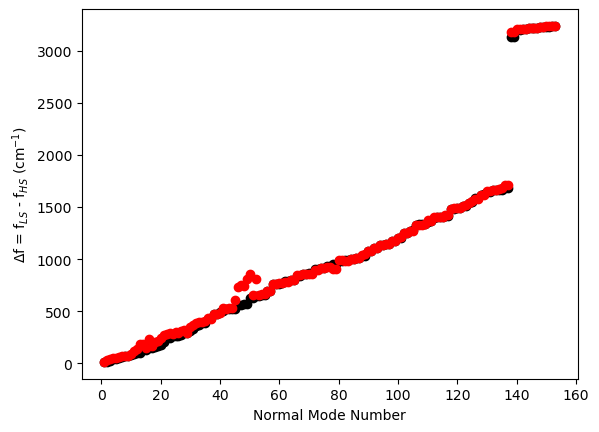

In [48]:
#plt.plot(Freq_Match['Label'],Freq_Match['Diff'],color = "black",marker='o')
plt.scatter(Freq_Match['Label'],Freq_Match['HS_freq'],color = "black")
plt.scatter(Freq_Match['Label'],Freq_Match['LS_eff_freq'],color = "red")
plt.ylabel(r'$\Delta$f = f$_{LS}$ - f$_{HS}$ (cm$^{-1}$)')
plt.xlabel('Normal Mode Number')
#plt.ylim(0,)
plt.show()

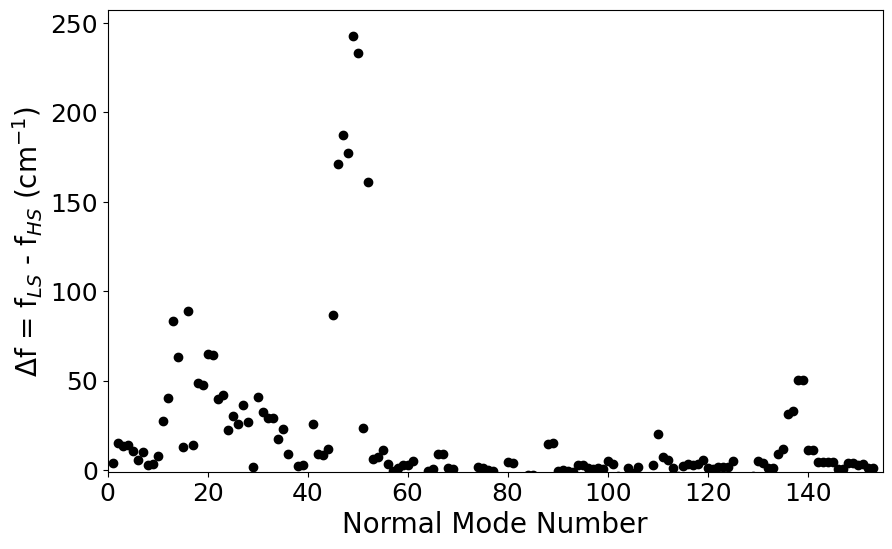

In [8]:
fig, ax = plt.subplots(figsize=(10,6))

#plt.plot(Freq_Match['Label'],Freq_Match['Diff'],
#         color="black", marker='o')

ax.scatter(
    Freq_Match['Label'],
    Freq_Match['Diff'],
    color="black"
)

ax.set_xlabel('Normal Mode Number', fontsize=20)

ax.set_ylabel(
    r'$\Delta$f = f$_{LS}$ - f$_{HS}$ (cm$^{-1}$)',
    fontsize=20
)

ax.tick_params(axis='both', labelsize=18)

ax.set_ylim(-1)
ax.set_xlim(0,155)

#plt.show()
plt.savefig(
    "fig_freq_diff.pdf",
    bbox_inches='tight'
)